In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import  mean_squared_error
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [4]:
df = pd.read_csv("IRIS.csv")
df = df.dropna()
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = df.drop(columns=['species'])
y = df.species

In [6]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,random_state=0)
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
dtree = DecisionTreeClassifier(random_state=0)
dtree.fit(X_train_s, y_train)
y_pred = dtree.predict(X_test_s)
conf = confusion_matrix(y_test, y_pred)
classif = classification_report(y_test, y_pred)
print("Confusion matrix: \n", conf)
print("Classification report: \n", classif)
#tree.plot_tree(dtree)
print(dtree.get_depth())

Confusion matrix: 
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
Classification report: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

5


In [7]:
df = pd.read_csv("IRIS.csv")
    #print(df.head())
df.dropna(inplace= True)
#scaler_standard = StandardScaler()
#scaler_minmax = MinMaxScaler()
X = df.drop(columns=['species'])
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y ,random_state=0)
dtree = DecisionTreeClassifier(random_state=0)
dtree.fit(X_train, y_train)
cv = cross_validate(dtree, X, y, cv=10, return_train_score=True)
print("Cross-Validation Results:")
print("Test: ",cv['test_score'])
print("Mean Test Accuracy:", cv['test_score'].mean())
print("Train scores:", cv['train_score'])
print("Mean Train Accuracy:", cv['train_score'].mean())

Cross-Validation Results:
Test:  [1.         0.93333333 1.         0.93333333 0.93333333 0.86666667
 0.93333333 1.         1.         1.        ]
Mean Test Accuracy: 0.96
Train scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Train Accuracy: 1.0


In [8]:
def pre_process_liver(df):
    df= df.drop('Gender', axis=1)
    df = df.dropna()
    df['Dataset'] = df['Dataset'].replace(2,0)
    df = df.rename(columns={'Dataset': 'Disease'})
    X = df.drop(columns=('Disease'))
    y = df.Disease
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled , y

In [9]:
df = pd.read_csv('indian_patient_records.zip')
X, y= pre_process_liver(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y ,random_state=0)
dtree2 = DecisionTreeClassifier(random_state=0, max_depth = 20)
dtree2.fit(X_train, y_train)
y_pred = dtree2.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[18 15]
 [15 68]]
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        33
           1       0.82      0.82      0.82        83

    accuracy                           0.74       116
   macro avg       0.68      0.68      0.68       116
weighted avg       0.74      0.74      0.74       116



[Text(0.5839658444022771, 0.9761904761904762, 'x[1] <= -0.268\ngini = 0.408\nsamples = 463\nvalue = [132, 331]'),
 Text(0.38045540796963945, 0.9285714285714286, 'x[3] <= -0.306\ngini = 0.483\nsamples = 292\nvalue = [119, 173]'),
 Text(0.4822106261859582, 0.9523809523809523, 'True  '),
 Text(0.24667931688804554, 0.8809523809523809, 'x[4] <= 0.18\ngini = 0.5\nsamples = 192\nvalue = [96, 96]'),
 Text(0.2314990512333966, 0.8333333333333334, 'x[0] <= -1.436\ngini = 0.499\nsamples = 186\nvalue = [96, 90]'),
 Text(0.1650853889943074, 0.7857142857142857, 'x[2] <= -0.478\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.14990512333965844, 0.7380952380952381, 'x[8] <= 1.575\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1347248576850095, 0.6904761904761905, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.1650853889943074, 0.6904761904761905, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.18026565464895636, 0.7380952380952381, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Tex

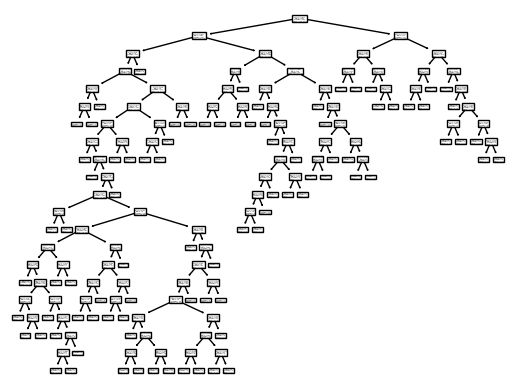

In [10]:
tree.plot_tree(dtree2)

In [11]:
print(dtree2.get_depth())

20


In [14]:
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('indian_patient_records.zip')
X, y= pre_process_liver(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y ,random_state=0)
dtree2 = RandomForestClassifier(random_state=0, n_estimators=500)
dtree2.fit(X_train, y_train)
y_pred = dtree2.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[14 19]
 [12 71]]
              precision    recall  f1-score   support

           0       0.54      0.42      0.47        33
           1       0.79      0.86      0.82        83

    accuracy                           0.73       116
   macro avg       0.66      0.64      0.65       116
weighted avg       0.72      0.73      0.72       116



In [15]:
dtree2.n_estimators

500